In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

#### LOAD ROLES

In [2]:
roles = pd.read_csv("../data/rolle.tsv", sep="\t")
roles.loc[len(roles)] = [-1, 'UNKNOWN']
roles.loc[len(roles)] = [-0, 'REGIE']
roles = roles.rename(columns={'rolleID': 'speaker_id'})
roles = roles.set_index('speaker_id')
roles

,name
speaker_id,
1,"Hitchcock, Erzähler"
2,"Justus Jonas, Erster Detektiv"
3,"Peter Shaw, Zweiter Detektiv"
4,"Bob Andrews, Recherchen und Archiv"
5,"Mr. Fentriss, Schriftsteller"
...,...
2484,Alyssa
2485,Conrad Wilmington
2486,Haley Darlow


#### LOAD COMBINED SCRIPTS

In [3]:
scripts = pd.read_csv('./combine.csv')
scripts = scripts.drop(columns=['Text','Page', 'Episode'])
scripts

,Speaker,speaker_id
0,REGIE,0
1,REGIE,0
2,REGIE,0
3,REGIE,0
4,REGIE,0
...,...,...
229028,Justus,2
229029,REGIE,0
229030,Peter,3
229031,Justus,2


#### GROUP BY SPEAKER ID AND COUNT

In [4]:
speaker_counts = scripts.groupby(by='speaker_id').count()
speaker_counts = speaker_counts.rename(columns={'Speaker': 'count'})
speaker_counts

,count
speaker_id,
-1,16288
0,20298
1,137
2,58718
3,33034
...,...
2447,97
2469,2
2472,10


#### JOIN AND ADD REAL NAMES

In [5]:
speaker_counts = speaker_counts.join(roles, how='left', on='speaker_id')
speaker_counts = speaker_counts.sort_values(by='count', ascending=False)
speaker_counts = speaker_counts.reset_index()
speaker_counts

,speaker_id,count,name
0,2,58718,"Justus Jonas, Erster Detektiv"
1,4,35571,"Bob Andrews, Recherchen und Archiv"
2,3,33034,"Peter Shaw, Zweiter Detektiv"
3,0,20298,REGIE
4,-1,16288,UNKNOWN
...,...,...,...
993,330,1,Sears
994,994,1,Gehilfe
995,334,1,Sekretärin
996,1004,1,Elvira Zuckerman


#### VISUALISE

In [6]:
# load gender
gender_df = pd.read_csv('../data/gender/gender.csv')
gender_df = gender_df.rename(columns={'rolleID': 'speaker_id'})
gender_df

,speaker_id,gender
0,1,m
1,2,m
2,3,m
3,4,m
4,5,m
...,...,...
404,2457,m
405,2460,f
406,2466,f
407,2467,m


In [7]:
speaker_counts_gender = pd.merge(speaker_counts, gender_df, on='speaker_id', how='left')
speaker_counts_gender.head(15)

,speaker_id,count,name,gender
0,2,58718,"Justus Jonas, Erster Detektiv",m
1,4,35571,"Bob Andrews, Recherchen und Archiv",m
2,3,33034,"Peter Shaw, Zweiter Detektiv",m
3,0,20298,REGIE,NaN
4,-1,16288,UNKNOWN,NaN
5,574,14088,Erzähler,NaN
6,436,1596,Inspektor Cotta,m
7,13,1045,Tante Mathilda,f
8,567,739,Clarissa Franklin,f
9,39,649,Kommissar Reynolds,m


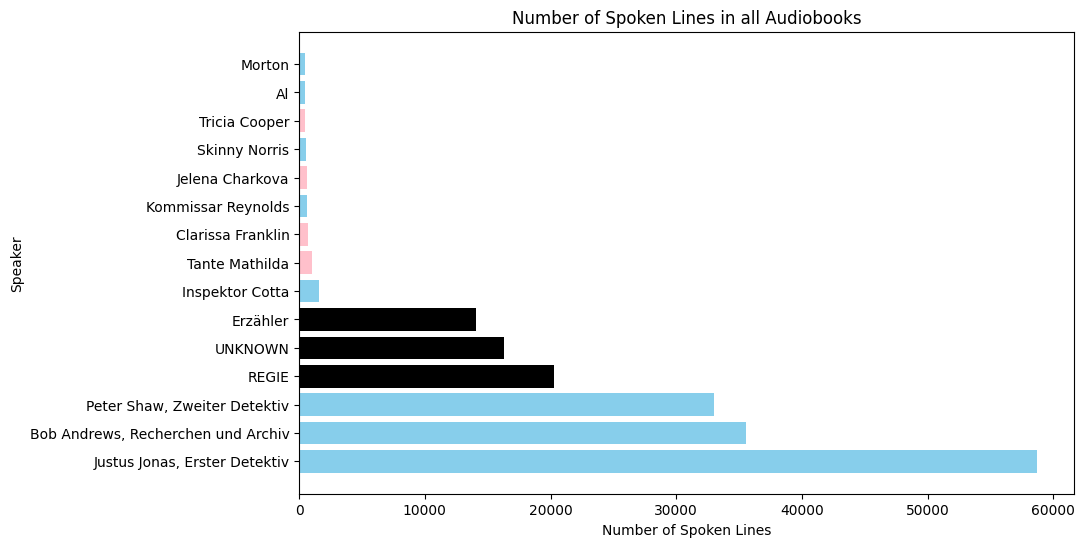

In [8]:
gender_colors = {'m': 'skyblue', 'f': 'pink', np.nan: 'black'}

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot each bar with the appropriate color
for i, row in speaker_counts_gender.head(15).iterrows():
    ax.barh(row['name'], row['count'], color=gender_colors[row['gender']])

plt.title('Number of Spoken Lines in all Audiobooks')
plt.xlabel('Number of Spoken Lines')
plt.ylabel('Speaker')
plt.show()

#### List names UNKNOWN

In [9]:
unknowns = scripts.where(
    scripts['speaker_id']==-1
).groupby(
    by='Speaker'
).count().rename(
    columns={'speaker_id' : 'count'}
).sort_values(by='count', ascending=False)
unknowns

,count
Speaker,
Kenneth O'Ryan,286
Jeremy,202
Joan,188
Kommissarin,180
Grace,170
...,...
Vanessa Goldstein,1
Wrenwick,1
Wick Hamil,1
